In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**1. LOAD AND CLEAN DATA**

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/healthcare_dataset.csv")
df.columns = df.columns.str.strip()


***Convert dates***

In [3]:
df["Date of Admission"] = pd.to_datetime(
    df["Date of Admission"], errors="coerce"
)

***Convert billing amount to numeric***

In [4]:
df["Billing Amount"] = pd.to_numeric(
    df["Billing Amount"], errors="coerce"
)

***Remove missing required values***

In [5]:
df = df.dropna(
    subset=[
        "Date of Admission",
        "Billing Amount",
        "Medical Condition",
        "Insurance Provider"
    ]
)

**2. STACKED BAR CHART**

 ***Billing Amount by Medical Condition and Insurance Provider***

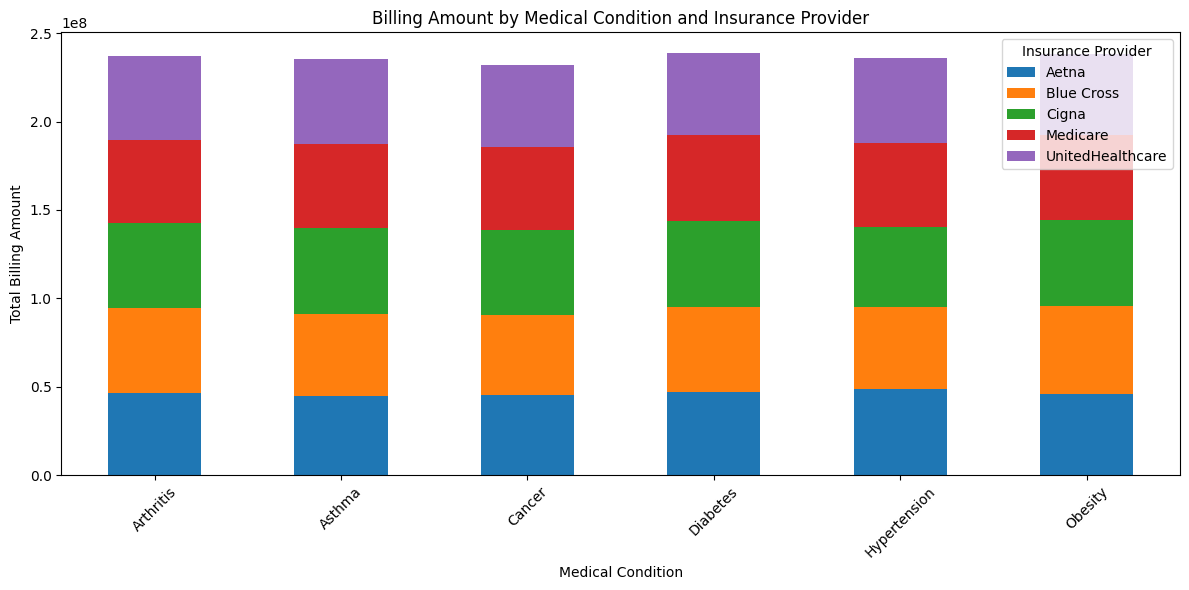

In [6]:
billing = pd.pivot_table(
    df,
    values="Billing Amount",
    index="Medical Condition",
    columns="Insurance Provider",
    aggfunc="sum"
)

billing.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Billing Amount by Medical Condition and Insurance Provider")
plt.xlabel("Medical Condition")
plt.ylabel("Total Billing Amount")
plt.xticks(rotation=45)
plt.legend(title="Insurance Provider")
plt.tight_layout()
plt.show()

**3. VIOLIN PLOT**

***Billing Amount by Medical Condition***

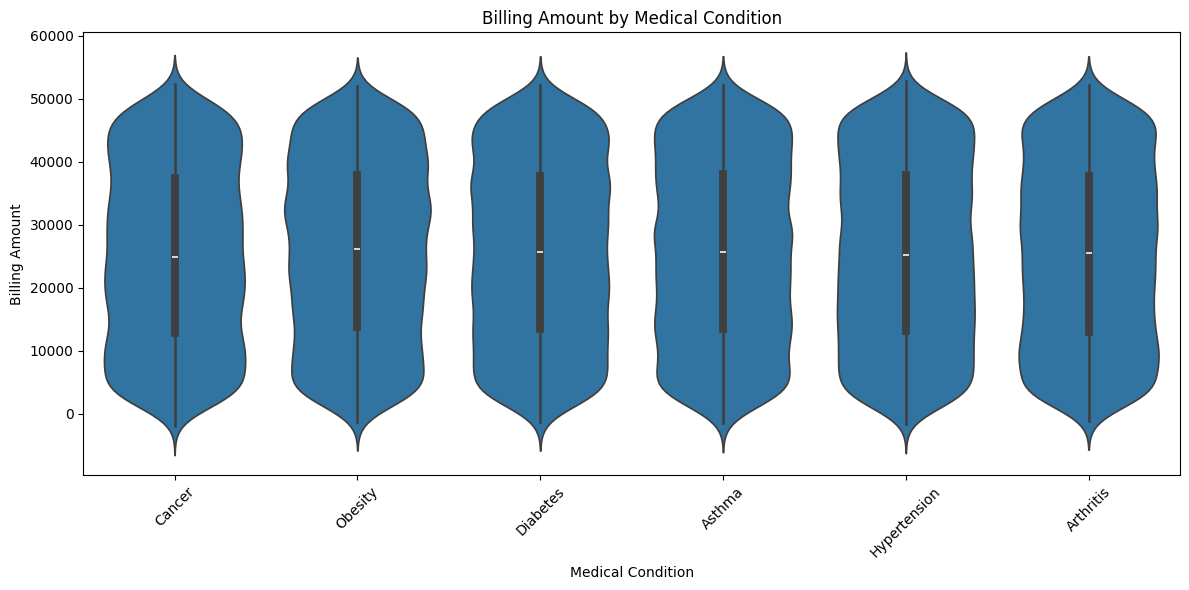

In [7]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x="Medical Condition",
    y="Billing Amount"
)

plt.title("Billing Amount by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Billing Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**4. VIOLIN PLOT**

***Billing Amount by Insurance Provider***

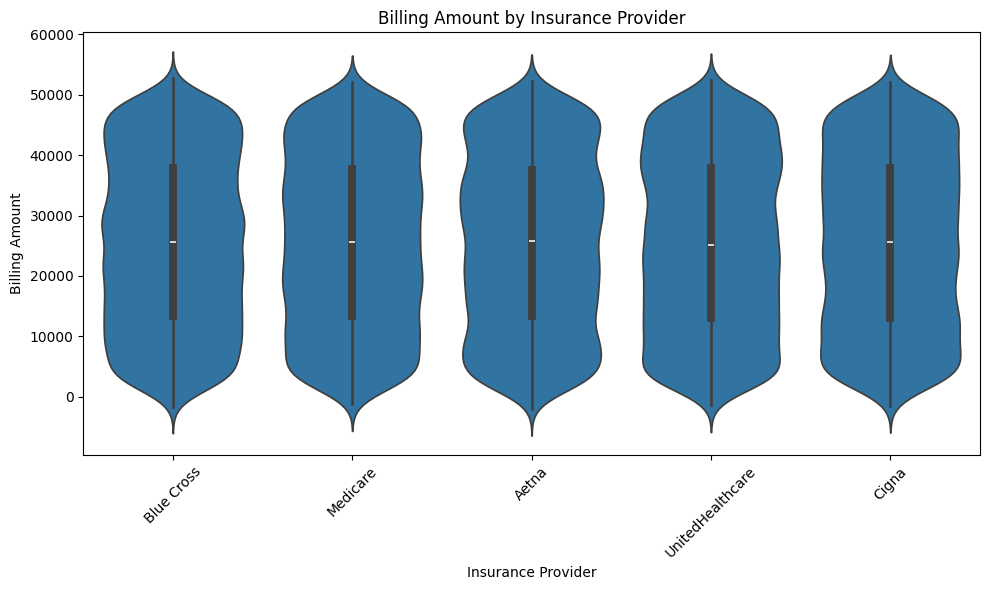

In [8]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="Insurance Provider",
    y="Billing Amount"
)

plt.title("Billing Amount by Insurance Provider")
plt.xlabel("Insurance Provider")
plt.ylabel("Billing Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**5. TEMPORAL LINE CHART**

***Patient Admissions Over Time***

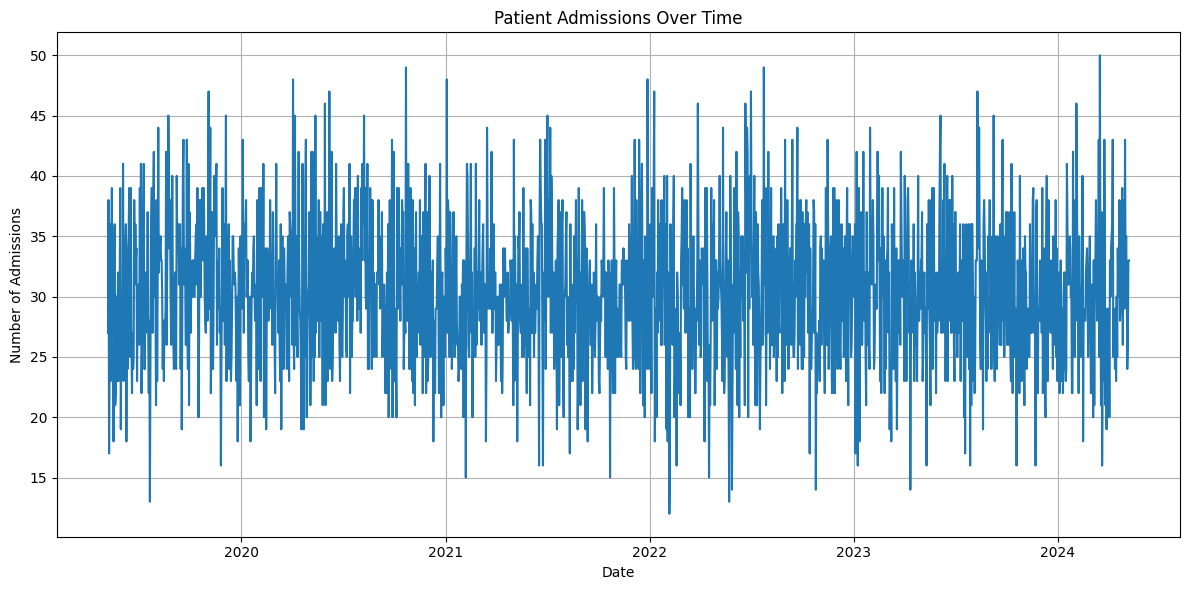

In [9]:
admissions = (
    df.groupby("Date of Admission")
      .size()
      .reset_index(name="Admissions")
)

plt.figure(figsize=(12, 6))

plt.plot(
    admissions["Date of Admission"],
    admissions["Admissions"]
)

plt.title("Patient Admissions Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Admissions")
plt.grid(True)
plt.tight_layout()
plt.show()

**6. MONTHLY ADMISSIONS**

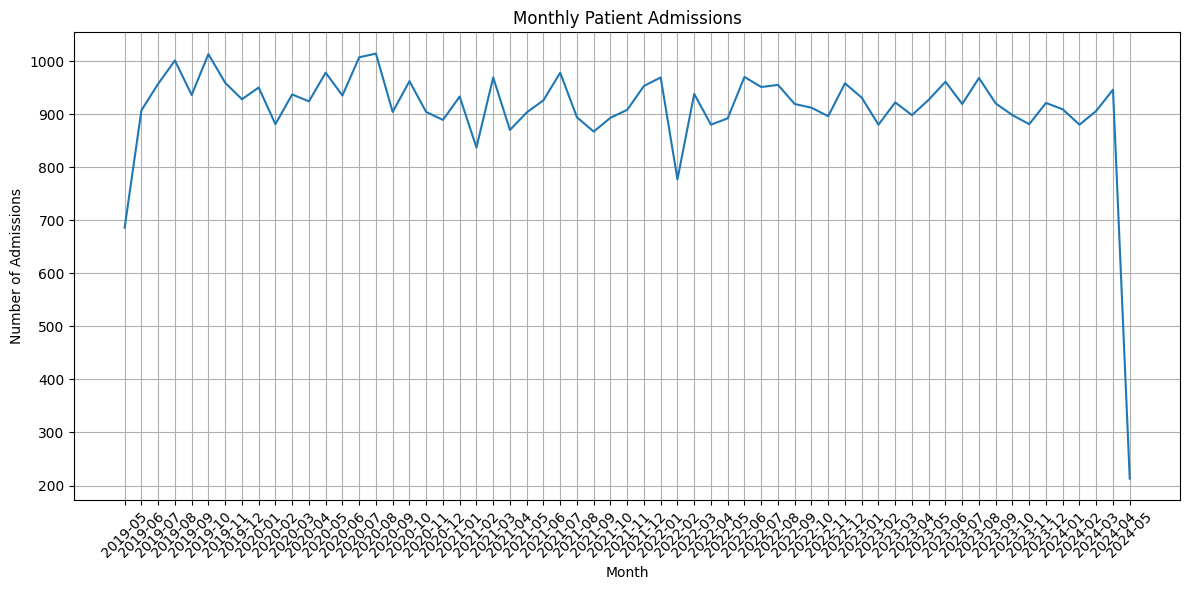

In [10]:
df["Month"] = df["Date of Admission"].dt.to_period("M")

monthly_admissions = df.groupby("Month").size()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_admissions.index.astype(str),
    monthly_admissions.values
)

plt.title("Monthly Patient Admissions")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

**7. HOSPITAL STAY DURATION**

In [13]:
if "Discharge Date" in df.columns:

    df["Discharge Date"] = pd.to_datetime(
        df["Discharge Date"], errors="coerce"
    )

    df["Stay Duration"] = (
        df["Discharge Date"] -
        df["Date of Admission"]
    ).dt.days

**8. CORRELATION MATRIX**

***Rename billing amount as total medical cost***


Correlation Matrix:
                         Age  Stay Duration  Total Medical Cost
Age                 1.000000       0.008220           -0.003832
Stay Duration       0.008220       1.000000           -0.005602
Total Medical Cost -0.003832      -0.005602            1.000000


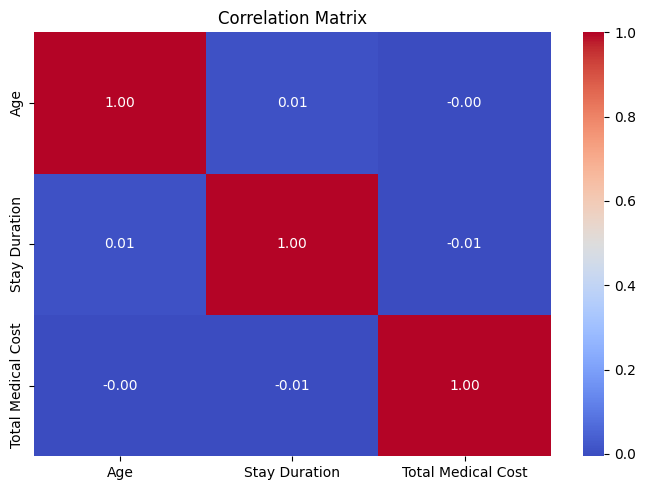

In [14]:
df["Total Medical Cost"] = df["Billing Amount"]

correlation_data = df[
    ["Age", "Stay Duration", "Total Medical Cost"]
].dropna()

correlation_matrix = correlation_data.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

**9. EXECUTIVE SUMMARY**

In [15]:
print("\n========== EXECUTIVE SUMMARY ==========")

print("\nAverage Billing Amount:",
      round(df["Billing Amount"].mean(), 2))

if "Stay Duration" in df.columns:
    print("Average Stay Duration:",
          round(df["Stay Duration"].mean(), 2),
          "days")

print("Total Admissions:", len(df))

print("\nManagement Recommendations:")
print("1. Monitor medical conditions with higher billing amounts.")
print("2. Review insurance-wise billing differences.")
print("3. Monitor months with unusually high patient admissions.")
print("4. Use stay duration and medical cost correlations to support resource planning.")
print("5. Allocate hospital resources according to admission trends.")


========== EXECUTIVE SUMMARY ==========

Average Billing Amount: 25539.32
Average Stay Duration: 15.51 days
Total Admissions: 55500

Management Recommendations:
1. Monitor medical conditions with higher billing amounts.
2. Review insurance-wise billing differences.
3. Monitor months with unusually high patient admissions.
4. Use stay duration and medical cost correlations to support resource planning.
5. Allocate hospital resources according to admission trends.
